In [2]:
import os
import glob
import json
import pprint
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset

from pyperf.utils.patch_parser import SimplePatchParser
from pyperf.harness.utils import natural_sort_key
from pyperf.constants import SUBMISSIONS_DIR, PLOTS_DIR
from pyperf.harness.scripts.helpers import *
from r2e.llms.completions import LLMCompletions
from r2e.llms.llm_args import LLMArgs

pd.set_option("future.no_silent_downcasting", True)
setup_plot_style()
pp = pprint.PrettyPrinter(indent=2)

#### Collect Dataset

In [2]:
dataset = load_dataset("manishs/pyperf-extended", split="test")
print(f"Filtered dataset size: {len(dataset)}")

Filtered dataset size: 105


In [3]:
def extract_codeblock(output) -> str:
    outputlines = output.split("\n")
    indexlines = [i for i, line in enumerate(outputlines) if "```" in line]
    if len(indexlines) < 2:
        return ""
    return "\n".join(outputlines[indexlines[0] + 1 : indexlines[1]])


def get_generated_codes(outputs, has_samples=True):
    results = []
    for output in outputs:
        if has_samples is False:
            res = extract_codeblock(output)
            results.append(res)
            continue

        sample_results = []
        for sample in output:
            res = extract_codeblock(sample)
            sample_results.append(res)
        results.append(sample_results)

    return results

In [4]:
ALGO_CLASSIFY_PROMPT = """You are a performance testing expert. You will generate a description of a performance improving commit for a Python repository.
    - The description MUST be KEYWORDS for the optimization idea and algorithms used to improve performance,
    - They can be general algorithms like e.g., Caching, Vectorization, Multiprocessing, SIMD, etc.
    - They can also be specific algorithms that are being applied to this scenario like e.g., BFS, LRU, Binary Search, Knuth-Welford variance algo, etc.
    - Do not include extremely nice details (e.g., code) that are only relevant to the commit. Keep it at the level of algorithmic ideas, general concepts, etc.

## Repo: {repo}
## Commit Message: {commit_message}

## Commit Diff:
{commit_diff}

Guidelines:
- Carefully read and try to understand the commit and interpret the changes made in the commit. Then, write a plan that describes the high-level idea of the optimization.
- Analyze carefully and try to classify the core algorithmic ideas used. Be as precise when possible.
- Each item in the description should be concise and clear and a like a algorithm name or idea name.
- Only focus on core optimization ideas.
- There can be multiple ideas in a commit, so write all the ideas used. Maximum 4 ideas.
- Completely ignore changes to comments, documentation, testing, formatting, CI, etc.
- ALSO ignore non-optimization changes like bug fixes, completely irrelevant feature additions, etc.

Respond in the following format enclosed in a code block with enumerated list:
```md
1. <optimization idea name 1>: 1 sentence description
2. <optimization idea name 2>: 1 sentence description
...
```
```
"""

In [5]:
llm_args = LLMArgs(
    model_name="o4-mini",
    max_tokens=24000,
    use_cache=False,
    temperature=0.5,
    multiprocess=50,
)


def prompt_o4_mini(instance):
    commit_diff = instance["gt_diff"]
    commit_message = instance["gt_commit_message"]
    repo = instance["repo"]
    prompt = ALGO_CLASSIFY_PROMPT.format(
        repo=repo, commit_message=commit_message, commit_diff=commit_diff
    )
    return prompt


payloads = []
for row in dataset:
    prompt = prompt_o4_mini(row)
    payloads.append([{"role": "user", "content": prompt}])

# outputs = LLMCompletions.get_llm_completions(llm_args, payloads)
# all_outputs = [item for sublist in outputs for item in sublist]

In [6]:
# add algos as a column to the dataset
# algos_found = get_generated_codes(all_outputs, has_samples=False)
# dataset_df = dataset.to_pandas()
# dataset_df["algos"] = algos_found

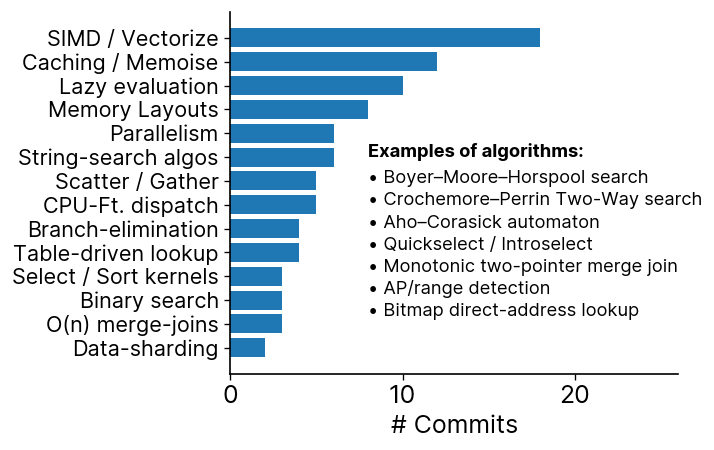

In [32]:
buckets = {
    "Caching / Memoise": 12,
    "Lazy evaluation": 10,
    "SIMD / Vectorize": 18,
    "Parallelism": 6,
    "String-search algos": 6,
    "Select / Sort kernels": 3,
    "Binary search": 3,
    "Scatter / Gather": 5,
    "Branch-elimination": 4,
    "Memory Layouts": 8,
    "Data-sharding": 2,
    "CPU-Ft. dispatch": 5,
    "Table-driven lookup": 4,
    "O(n) merge-joins": 3,
}

algorithms = [
    "Boyer–Moore–Horspool search",
    "Crochemore–Perrin Two-Way search",
    "Aho–Corasick automaton",
    "Quickselect / Introselect",
    "Monotonic two-pointer merge join",
    "AP/range detection",
    "Bitmap direct-address lookup",
]

# ---------------------------
# Pre‑processing
# ---------------------------
# Sort buckets by commit count (descending)
labels = sorted(buckets, key=buckets.get, reverse=True)
counts = [buckets[label] for label in labels]

# ---------------------------
# Figure & Axes
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# ---------------------------
# Bar chart
# ---------------------------
bars = ax.barh(labels, counts)
ax.set_xlabel("# Commits")
ax.invert_yaxis()  # largest at top

# set y label font size
ax.tick_params(axis="y", labelsize=13)

# Set x-axis limit to include space for text
ax.set_xlim(0, max(counts) + 8)  # Adjust value if needed

# ---------------------------
# Algorithm list directly as text annotations
# ---------------------------
# Position text after the longest bar
text_x = 8.0  # max(counts) + 0.8

# Get the y-positions of the bars from the bar container
bar_positions = [bar.get_y() + bar.get_height() / 2 for bar in bars]

# Calculate the range of y values in the plot
y_min, y_max = min(bar_positions), max(bar_positions)
total_height = abs(y_max - y_min)
title_y = y_min + 5.0
ax.text(text_x, title_y, "Examples of algorithms:", fontsize=11, fontweight="bold")

# Tighter spacing for algorithm items
alg_spacing = total_height / (len(algorithms) * 2)
alg_start = y_min + 6.1

for i, algo in enumerate(algorithms):
    y_pos = alg_start + i * alg_spacing
    ax.text(text_x, y_pos, f"• {algo}", fontsize=11)

# ---------------------------
# Layout & Output
# ---------------------------
plt.tight_layout()
plt.savefig("plots/algos_dist.png", dpi=300, bbox_inches="tight")
plt.show()

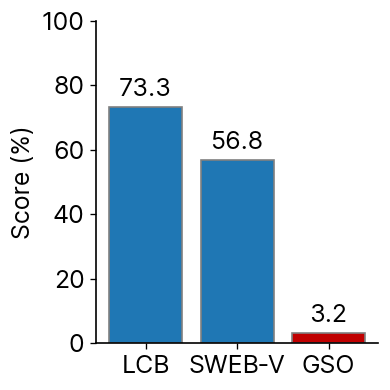

In [3]:
# Data
labels = ["LCB", "SWEB‑V", "GSO"]
values = [73.3, 56.8, 3.2]
first_blue = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]
colors = [first_blue, first_blue, "#c00000"]
hatches = ["///", "///", None]  # hatch pattern for first two bars

# Create figure
fig, ax = plt.subplots(figsize=(3.5, 3.5))

# Plot bars
bars = ax.bar(labels, values, color=colors, edgecolor="gray")

# Annotate value labels above bars
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position
        val + 2,  # y position (slightly above bar)
        f"{val:.1f}",  # label text
        ha="center",
        va="bottom",
        # fontweight="bold",
    )

# Style axes
ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
# ax.set_xlabel("Benchmarks")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("plots/bench_comparison.png", dpi=300, bbox_inches="tight")
plt.show()